--- Задача 1 ---
Форма DataFrame: (10000, 50)

Типы данных (первые 10 колонок):
col_1       str
col_2     int64
col_3     int64
col_4       str
col_5     int64
col_6     int64
col_7       str
col_8     int64
col_9     int64
col_10      str
dtype: object

Пропуски в данных:
col_1     0
col_2     0
col_3     0
col_4     0
col_5     0
col_6     0
col_7     0
col_8     0
col_9     0
col_10    0
dtype: int64

Первые 5 строк:
    col_1  col_2  col_3        col_4  col_5  col_6     col_7  col_8  col_9  \
0    Home    762    303  Electronics     49    348  Clothing    206    123   
1  Sports    190     34       Sports    107     99  Clothing    836    775   
2   Books    711      2         Home     93    876      Home    868     69   
3  Sports    484    362        Books    636    361      Home    897    111   
4  Sports    733    195         Home    829    937  Clothing    428    871   

        col_10  ...  col_41  col_42    col_43  col_44  col_45       col_46  \
0       Sports  ...     676  

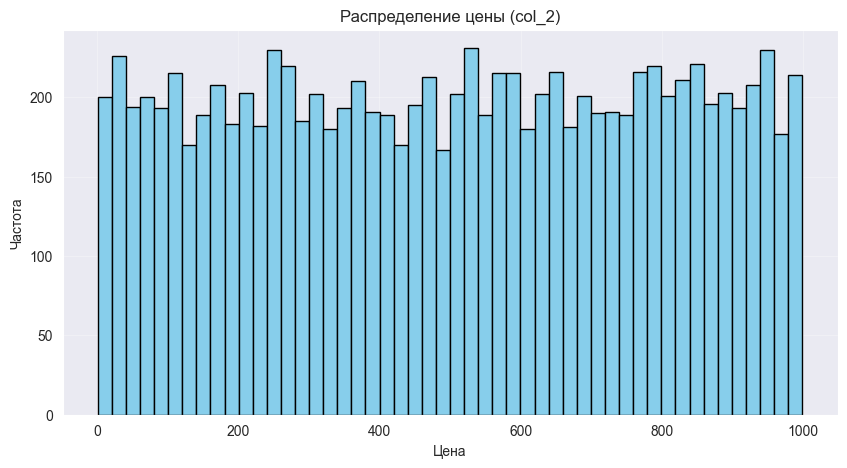

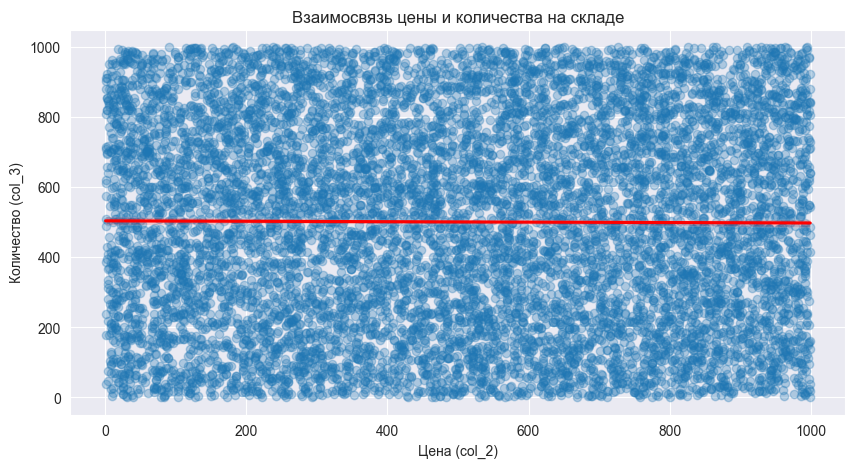

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#1
df = pd.read_excel('catalog_products.xlsx')

print(f"--- Задача 1 ---")
print(f"Форма DataFrame: {df.shape}")
print("\nТипы данных (первые 10 колонок):")
print(df.dtypes.head(10))
print("\nПропуски в данных:")
print(df.isnull().sum().head(10))
print("\nПервые 5 строк:")
print(df.head())

#2
numeric_cols = [f'col_{i}' for i in range(2, 51)]

for col in numeric_cols:
    if col in df.columns:
        # Переводим в float (errors='coerce' превратит текст в NaN)
        df[col] = pd.to_numeric(df[col], errors='coerce')
        # Заполняем пропуски средним
        df[col] = df[col].fillna(df[col].mean())


print("Числовые данные приведены к float, пропуски заполнены средним.")

#3
df['total_value'] = df['col_2'] * df['col_3']  # Цена * Склад
df['double_stock'] = df['col_4'] * 2           # Удвоенный запас
df['log_price'] = np.log1p(df['col_2'])        # Логарифм цены (+1 для стабильности)

#4
electronics_expensive = df[(df['col_2'] > 500) & (df['col_7'] == 'Electronics')]

print(f"\n--- Задача 4 ---")
print("Найдено дорогих товаров в категории Electronics:", len(electronics_expensive))

#5
category_stats = df.groupby('col_7').agg(
    mean_price=('col_2', 'mean'),
    max_price=('col_2', 'max'),
    total_quantity=('col_3', 'sum')
).reset_index()

#6
cols_subset = [f'col_{i}' for i in range(2, 12)]
summary_stats = pd.DataFrame({
    'column': cols_subset,
    'mean': [df[c].mean() for c in cols_subset],
    'median': [df[c].median() for c in cols_subset],
    'std': [df[c].std() for c in cols_subset]
})

#7
mean_p = df['col_2'].mean()
std_p = df['col_2'].std()
anomalies = df[df['col_2'] > (mean_p + 3 * std_p)]

print(f"\n--- Задача 7 ---")
print(f"Выявлено аномалий по цене: {len(anomalies)}")

#8
corr_matrix = df[cols_subset].corr()

#9
plt.figure(figsize=(10, 5))
plt.hist(df['col_2'], bins=50, color='skyblue', edgecolor='black')
plt.title('Распределение цены (col_2)')
plt.xlabel('Цена')
plt.ylabel('Частота')
plt.grid(True, alpha=0.3)
plt.show()

#10
plt.figure(figsize=(10, 5))
sns.regplot(data=df, x='col_2', y='col_3', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Взаимосвязь цены и количества на складе')
plt.xlabel('Цена (col_2)')
plt.ylabel('Количество (col_3)')
plt.show()

In [ ]:
#1
df = pd.read_excel('catalog_products.xlsx')

print(f"--- Задача 1 ---")
print(f"Форма DataFrame: {df.shape}")
print("\nТипы данных (первые 10 колонок):")
print(df.dtypes.head(10))
print("\nПропуски в данных:")
print(df.isnull().sum().head(10))
print("\nПервые 5 строк:")
print(df.head())

In [ ]:
#2
numeric_cols = [f'col_{i}' for i in range(2, 51)]

for col in numeric_cols:
    if col in df.columns:
        # Переводим в float (errors='coerce' превратит текст в NaN)
        df[col] = pd.to_numeric(df[col], errors='coerce')
        # Заполняем пропуски средним
        df[col] = df[col].fillna(df[col].mean())


print("Числовые данные приведены к float, пропуски заполнены средним.")

In [ ]:
#3
df['total_value'] = df['col_2'] * df['col_3']  # Цена * Склад
df['double_stock'] = df['col_4'] * 2           # Удвоенный запас
df['log_price'] = np.log1p(df['col_2'])        # Логарифм цены (+1 для стабильности)

In [ ]:
#4
electronics_expensive = df[(df['col_2'] > 500) & (df['col_7'] == 'Electronics')]

print(f"\n--- Задача 4 ---")
print("Найдено дорогих товаров в категории Electronics:", len(electronics_expensive))

In [ ]:
#5
category_stats = df.groupby('col_7').agg(
    mean_price=('col_2', 'mean'),
    max_price=('col_2', 'max'),
    total_quantity=('col_3', 'sum')
).reset_index()

In [ ]:
#6
cols_subset = [f'col_{i}' for i in range(2, 12)]
summary_stats = pd.DataFrame({
    'column': cols_subset,
    'mean': [df[c].mean() for c in cols_subset],
    'median': [df[c].median() for c in cols_subset],
    'std': [df[c].std() for c in cols_subset]
})

In [ ]:

#7
mean_p = df['col_2'].mean()
std_p = df['col_2'].std()
anomalies = df[df['col_2'] > (mean_p + 3 * std_p)]

print(f"\n--- Задача 7 ---")
print(f"Выявлено аномалий по цене: {len(anomalies)}")

In [ ]:
#8
corr_matrix = df[cols_subset].corr()

In [ ]:
#9
plt.figure(figsize=(10, 5))
plt.hist(df['col_2'], bins=50, color='skyblue', edgecolor='black')
plt.title('Распределение цены (col_2)')
plt.xlabel('Цена')
plt.ylabel('Частота')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
#10
plt.figure(figsize=(10, 5))
sns.regplot(data=df, x='col_2', y='col_3', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Взаимосвязь цены и количества на складе')
plt.xlabel('Цена (col_2)')
plt.ylabel('Количество (col_3)')
plt.show()